<a href="https://colab.research.google.com/github/ksbrn-coder/AI-26/blob/main/AI_%EA%B8%B0%EB%B0%98_%EC%98%88%EC%B8%A1_%EB%B0%8F_%EB%B6%84%EC%84%9D_%EA%B8%B0%EC%88%A0_%EC%8B%9C%ED%97%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. 더미데이터 준비

import tensorflow as tf

tf.keras.utils.set_random_seed(39)
tf.config.experimental.enable_op_determinism()

from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) =\
keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=39)

In [2]:
# 2. 훈련 / 검증 / 테스트데이터 shape 확인

print("훈련 데이터 : ")
print(train_scaled.shape, train_target.shape)
print("테스트 데이터 : ")
print(test_input.shape, test_target.shape)
print("검증 데이터 : ")
print(val_scaled.shape, val_target.shape)

훈련 데이터 : 
(48000, 28, 28) (48000,)
테스트 데이터 : 
(10000, 28, 28) (10000,)
검증 데이터 : 
(12000, 28, 28) (12000,)


In [4]:
# 3. 모델용 객체 메서드 생성

def model_fn(a_layer=None):
  model = keras.Sequential()
  model.add(keras.layers.Flatten(input_shape=(28, 28))) # 입력층
  model.add(keras.layers.Dense(100, activation='relu')) # 2진분류층

  if a_layer:
    model.add(a_layer) # 매개값으로 넘어오는 추가되는 층
  model.add(keras.layers.Dense(10, activation='softmax')) # 출력층
  return model

In [5]:
# 메서드 호출 후 모델에 담고, 요약 정보 확인
model = model_fn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 4. 다중 분류를 이용한 컴파일
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [8]:
# 5. 훈련 시작
history = model.fit(train_scaled, train_target, epochs=8, verbose=2)

Epoch 1/8
1500/1500 - 6s - 4ms/step - accuracy: 0.8927 - loss: 0.3027
Epoch 2/8
1500/1500 - 4s - 3ms/step - accuracy: 0.8985 - loss: 0.2910
Epoch 3/8
1500/1500 - 4s - 3ms/step - accuracy: 0.9019 - loss: 0.2815
Epoch 4/8
1500/1500 - 5s - 3ms/step - accuracy: 0.9059 - loss: 0.2742
Epoch 5/8
1500/1500 - 4s - 3ms/step - accuracy: 0.9089 - loss: 0.2676
Epoch 6/8
1500/1500 - 4s - 2ms/step - accuracy: 0.9101 - loss: 0.2604
Epoch 7/8
1500/1500 - 5s - 3ms/step - accuracy: 0.9136 - loss: 0.2536
Epoch 8/8
1500/1500 - 4s - 3ms/step - accuracy: 0.9151 - loss: 0.2489


In [9]:
print(history)
print(history.history.keys())

dict_keys(['accuracy', 'loss'])


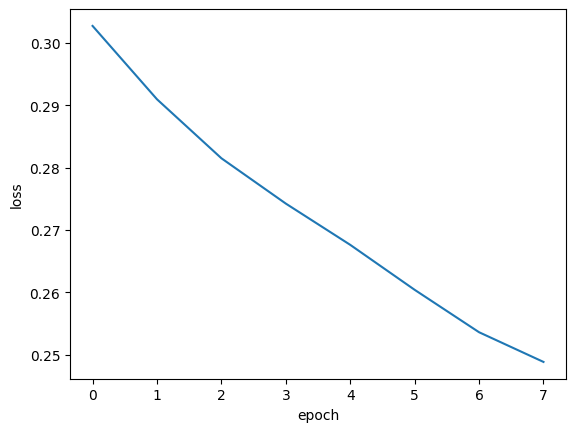

In [10]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

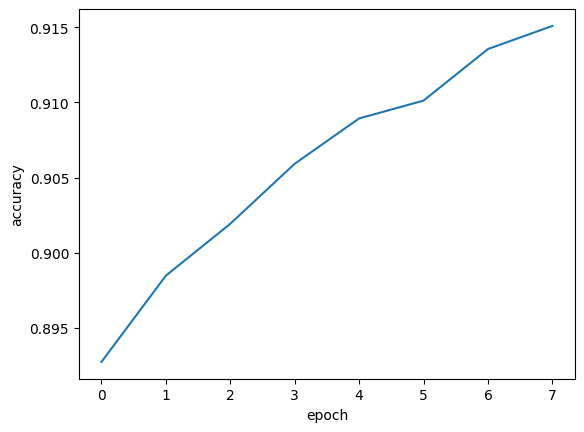

In [12]:
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [13]:
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


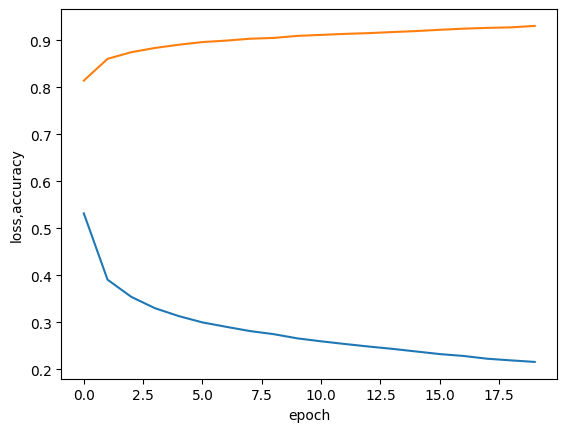

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss,accuracy')
plt.show()

In [15]:
# 검증 손실을 구하기 위한 매개값 추가

moedl = model_fn()
model.summary()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=1,
                    validation_data=(val_scaled, val_target))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,022 (621.18 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 79,512 (310.60 KB)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9278 - loss: 0.2239 - val_accuracy: 0.8762 - val_loss: 0.5008
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9310 - loss: 0.2169 - val_accuracy: 0.8755 - val_loss: 0.5166
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9329 - loss: 0.2138 - val_accuracy: 0.8801 - val_loss: 0.5279
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9345 - loss: 0.2086 - val_accuracy: 0.8804 - val_loss: 0.5284
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9349 - loss: 0.2070 - val_accuracy: 0.8742 - val_loss: 0.5750
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9356 - loss: 0.2063 - val_accuracy: 0.8761 - val_loss: 0.5628
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9393 - loss: 0.1983 - val_accuracy: 0.8774 - val_loss: 0.5534
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9387 - loss: 0.1973 -

In [16]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


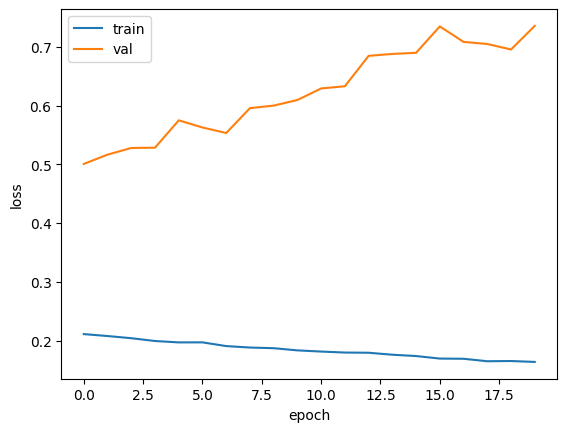

In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','val'])
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


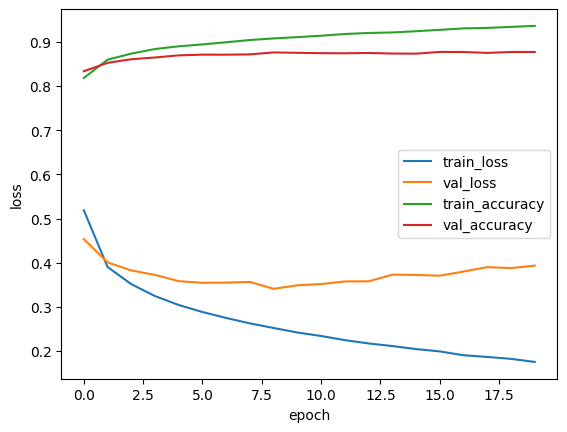

In [18]:
# 6. 최적화 기법 사용(Adam)

model = model_fn()
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
              metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss','val_loss', 'train_accuracy', 'val_accuracy'])
plt.show()

In [19]:
# 7. 과대 적합을 막는 기술 (드롭 아웃)
model = model_fn(keras.layers.Dropout(0.4))

# 8. 모델 요약
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

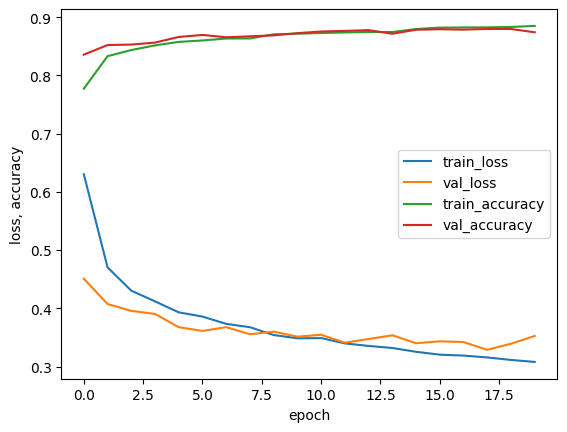

In [20]:
# 9. 훈련 결과를 그래프로 출력

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
              metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0, validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['train_loss','val_loss', 'train_accuracy', 'val_accuracy'])
plt.show()

In [25]:
# 10. 모델 저장

model = model_fn(keras.layers.Dropout(0.4))
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
              metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=10, verbose=0,
                    validation_data=(val_scaled, val_target))
model.save('model-whole-ep10.keras') # 저장
model.save_weights('model-ep10.weights.h5') # HDF5 형식으로도 저장

In [27]:
# 11. 모델을 불러와 테스트 진행
!ls -al model*

-rw-r--r-- 1 root root 976600 Mar  6 06:25 model-ep10.weights.h5
-rw-r--r-- 1 root root 979409 Mar  6 06:25 model-whole-ep10.keras


In [28]:
# 실험 1
model = model_fn(keras.layers.Dropout(0.3))
model.load_weights('model-ep10.weights.h5')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
import numpy as np
val_labels = np.argmax(model.predict(val_scaled), axis=-1)
print(np.mean(val_labels == val_target))

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
0.8681666666666666


In [31]:
model = keras.models.load_model('model-whole-ep10.keras')
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8666 - loss: 0.3585


[0.35591936111450195, 0.8681666851043701]

In [32]:
# 실험 2

model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
              metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras',
                                                save_best_only=True)
model.fit(train_scaled, train_target, epochs=20, verbose=1,
          validation_data=(val_scaled, val_target),
          callbacks=[checkpoint_cb])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7286 - loss: 0.7770 - val_accuracy: 0.8358 - val_loss: 0.4325
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8408 - loss: 0.4523 - val_accuracy: 0.8502 - val_loss: 0.3971
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8546 - loss: 0.4106 - val_accuracy: 0.8581 - val_loss: 0.3854
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8578 - loss: 0.3913 - val_accuracy: 0.8593 - val_loss: 0.3712
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8651 - loss: 0.3730 - val_accuracy: 0.8642 - val_loss: 0.3593
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8674 - loss: 0.3667 - val_accuracy: 0.8698 - val_loss: 0.3498
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8703 - loss: 0.3524 - val_accuracy: 0.8717 - val_loss: 0.3525
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8745 - loss: 0.340

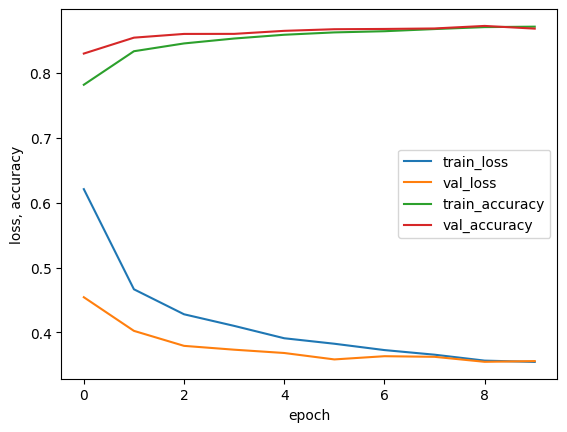

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8755 - loss: 0.3459


[0.3444919288158417, 0.8784999847412109]

In [35]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['train_loss', 'val_loss', 'train_accuracy', 'val_accuracy'])
plt.show()

model.evaluate(val_scaled, val_target)

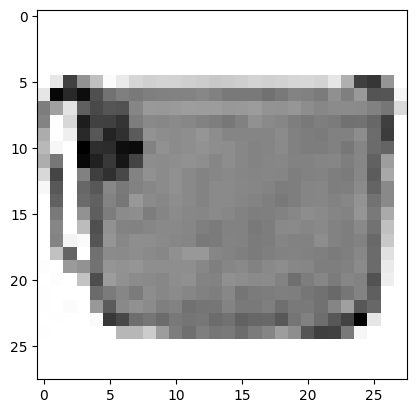

In [36]:
plt.imshow(val_scaled[15].reshape(28,28),cmap='gray_r')
plt.show()

In [37]:
print("15번 데이터의 레이블 번호:", val_target[15])

15번 데이터의 레이블 번호: 8
